# GEC DELCODE Whole-Brain Classifier with 5-Fold Stratified Cross-Validation

In [1]:
import sys
from pathlib import Path

model_root = Path('/mnt/e/fyassine/ad-early-detection/MODEL')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(model_root))

print(f'Added to sys.path: {model_root}')

Added to sys.path: /mnt/e/fyassine/ad-early-detection/MODEL


In [2]:
import json
import numpy as np
import os
import torch
import wandb
import pandas as pd
import seaborn as sns

from collections import OrderedDict
from pathlib import Path
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
from torch_geometric.loader import DataLoader
from copy import deepcopy
from datetime import datetime

from model.GEC.dataset import ClassificationDataset, CombinedClassificationDataset
from model.GEC.models import GraphEncoderClassifierAttention
from model.GEC.utils import load_frozen_encoder_from_gaae, compute_class_weights
from model.GEC.utils import knn_binary_adjacency_matrix_no_diag
from model.GEC.train import train_classifier
sns.set(style="whitegrid")

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Configuration

In [4]:
try:
    wandb.login()
except Exception:
    pass

WANDB_PROJECT = "gec-converter-classification-whole-brain"

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/wunderlich/.netrc.
wandb: Currently logged in as: lakhalfrajyassine (lakhalfrajyassine-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
# Whole-brain data and metadata paths
WB_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v3__/matrices'
METADATA_DIR = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v3__/metadata'
GAAE_SPLITS_DIR = os.path.join(METADATA_DIR, 'splits_gaae') if os.path.exists(os.path.join(METADATA_DIR, 'splits_gaae')) else os.path.join('/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/metadata', 'splits_gaae')
TRAIN_SPLIT_CSV = os.path.join(GAAE_SPLITS_DIR, 'train.csv')
VAL_SPLIT_CSV = os.path.join(GAAE_SPLITS_DIR, 'val.csv')
TEST_SPLIT_CSV = os.path.join(GAAE_SPLITS_DIR, 'test.csv')

CHECKPOINT_SEARCH_DIRS = [
    str(model_root / 'notebooks' / 'checkpoints_gaae_whole_brain'),
]

# GEC output directory
GEC_OUTPUT_DIR = str(model_root / 'notebooks' / 'checkpoints_gec_whole_brain')
os.makedirs(GEC_OUTPUT_DIR, exist_ok=True)

IN_FEATURES = 400
HIDDEN_DIM = 400
LATENT_DIM = 32
COND_DIM = 2
NUM_HEADS = 2
DROPOUT = 0.5
CLASSIFIER_HIDDEN = 32

BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 25
EARLY_STOPPING_PATIENCE = 30

KNN_K = 8
adjacency_args = {'k': KNN_K}
CORRELATION_TYPE = 'whole_brain'
FILE_VARIANT = 'z_transformed'

FREEZE_ENCODER = False
CLASSIFICATION_THRESHOLD = 0.35

N_FOLDS = 5
RANDOM_STATE = 42

In [6]:
checkpoint_candidates = sorted(
    [
        (run_dir.name, str(model_file), str(run_dir))
        for checkpoint_dir in CHECKPOINT_SEARCH_DIRS
        for base_dir in [Path(checkpoint_dir)]
        if base_dir.is_dir()
        for run_dir in sorted(base_dir.iterdir())
        if run_dir.is_dir()
        for model_file in [run_dir / f"model_{run_dir.name}.pth"]
        if model_file.exists()
    ],
    key=lambda x: x[0],
)

if not checkpoint_candidates:
    raise FileNotFoundError(
        'No GAAE checkpoints found. Train MODEL/notebooks/GAAE_DELCODE_WHOLE_BRAIN.ipynb first.'
    )

print('Available checkpoints:')
for i, (run_name, _, run_dir) in enumerate(checkpoint_candidates):
    print(f'  {i}: {run_name} ({run_dir})')

selected_run_index = int(input('Select a checkpoint by index: '))
RUN_NAME, GAAE_CHECKPOINT_PATH, SELECTED_RUN_DIR = checkpoint_candidates[selected_run_index]

run_config_path = Path(SELECTED_RUN_DIR) / 'run_config.json'
if run_config_path.exists():
    with open(run_config_path, 'r') as f:
        run_config = json.load(f)
    model_cfg = run_config.get('model_config', {})
    IN_FEATURES = int(model_cfg.get('in_features', IN_FEATURES))
    HIDDEN_DIM = int(model_cfg.get('hidden_size', HIDDEN_DIM))
    LATENT_DIM = int(model_cfg.get('latent_dim', LATENT_DIM))
    NUM_HEADS = int(model_cfg.get('attention_heads', NUM_HEADS))
    DROPOUT = float(model_cfg.get('dropout', DROPOUT))
    print(f"Loaded run config from {run_config_path}")

print(f'Using checkpoint: {GAAE_CHECKPOINT_PATH}')
print(f'Configured dims: in={IN_FEATURES}, latent={LATENT_DIM}, heads={NUM_HEADS}, dropout={DROPOUT}')

Available checkpoints:
  0: worldly-plasma-2_2026-03-24_01-00-18 (/mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18)
Loaded run config from /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/run_config.json
Using checkpoint: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/model_worldly-plasma-2_2026-03-24_01-00-18.pth
Configured dims: in=200, latent=64, heads=2, dropout=0.3


In [7]:
if not os.path.exists(GAAE_CHECKPOINT_PATH):
    raise FileNotFoundError(f'Checkpoint not found: {GAAE_CHECKPOINT_PATH}')
print(f'Checkpoint ready: {GAAE_CHECKPOINT_PATH}')

Checkpoint ready: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/model_worldly-plasma-2_2026-03-24_01-00-18.pth


## Load Datasets

In [8]:
split_paths = {
    'train': TRAIN_SPLIT_CSV,
    'val': VAL_SPLIT_CSV,
    'test': TEST_SPLIT_CSV,
}
split_frames = {name: pd.read_csv(path) for name, path in split_paths.items()}

base_required_cols = {'Repseudonym', 'sex', 'age'}
for name, df in split_frames.items():
    missing_base = base_required_cols - set(df.columns)
    assert not missing_base, f"Split {name}.csv missing columns: {missing_base}"

    if 'converter_status' not in df.columns:
        assert 'diagnosis' in df.columns, (
            f"Split {name}.csv must contain either converter_status or diagnosis"
        )
        df = df.copy()
        df['converter_status'] = (
            df['diagnosis'].astype(str).str.lower().str.strip() == 'converter'
        ).astype(int)
    else:
        df = df.copy()
        conv = pd.to_numeric(df['converter_status'], errors='coerce')
        if conv.isna().any():
            assert 'diagnosis' in df.columns, (
                f"Split {name}.csv has invalid converter_status and no diagnosis fallback"
            )
            fallback = (
                df['diagnosis'].astype(str).str.lower().str.strip() == 'converter'
            ).astype(int)
            conv = conv.fillna(fallback)
        df['converter_status'] = conv.astype(int)

    split_frames[name] = df

all_splits_df = pd.concat(split_frames.values(), ignore_index=True)
all_splits_df = all_splits_df.drop_duplicates(subset=['Repseudonym'], keep='first')
all_splits_df['Repseudonym'] = all_splits_df['Repseudonym'].astype(str)

patient_info_df = all_splits_df[['Repseudonym', 'sex', 'age']].rename(
    columns={'Repseudonym': 'Pseudonym'}
).set_index('Pseudonym')

status_by_id = all_splits_df.set_index('Repseudonym')['converter_status'].to_dict()
converter_ids = sorted(pid for pid, status in status_by_id.items() if status == 1)
non_converter_ids = sorted(pid for pid, status in status_by_id.items() if status == 0)

import tempfile
patient_info_path = tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False).name
patient_info_df.to_csv(patient_info_path)

converter_dataset = ClassificationDataset(
    root=WB_ROOT,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    patient_info_path=patient_info_path,
    is_converter_dataset=True,
    separator=',',
    correlation_type=CORRELATION_TYPE,
    subject_ids=converter_ids,
    file_variant=FILE_VARIANT,
    filter_csv_path=None,
    converter_list_path=None,
)

mci_stable_dataset = ClassificationDataset(
    root=WB_ROOT,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    patient_info_path=patient_info_path,
    is_converter_dataset=False,
    separator=',',
    correlation_type=CORRELATION_TYPE,
    subject_ids=non_converter_ids,
    file_variant=FILE_VARIANT,
    filter_csv_path=None,
    converter_list_path=None,
)

print(f"Converter dataset size: {len(converter_dataset)}")
print(f"Non-converter dataset size: {len(mci_stable_dataset)}")

Converter dataset size: 196
Non-converter dataset size: 402


In [9]:
combined_dataset = CombinedClassificationDataset(converter_dataset, mci_stable_dataset)
all_labels = combined_dataset.get_labels()

print(f"\nCombined dataset:")
print(f"  Total samples: {len(combined_dataset)}")
print(f"  Converters: {sum(all_labels)} ({sum(all_labels)/len(all_labels)*100:.1f}%)")
print(f"  Non-converters: {len(all_labels) - sum(all_labels)} ({(len(all_labels)-sum(all_labels))/len(all_labels)*100:.1f}%)")


Combined dataset:
  Total samples: 598
  Converters: 196.0 (32.8%)
  Non-converters: 402.0 (67.2%)


## Load Splits from Whole-Brain Metadata CSVs

Train + validation IDs are used as the cross-validation pool.
Test IDs are used as the holdout set.

In [10]:
train_ids = set(split_frames['train']['Repseudonym'].astype(str))
val_ids = set(split_frames['val']['Repseudonym'].astype(str))
test_ids = set(split_frames['test']['Repseudonym'].astype(str))

patient_to_indices = {}
for idx in range(len(combined_dataset)):
    patient_id = str(getattr(combined_dataset[idx], 'patient_id', ''))
    patient_to_indices.setdefault(patient_id, []).append(idx)

def get_split_indices(patient_ids):
    indices = []
    for pid in patient_ids:
        indices.extend(patient_to_indices.get(str(pid), []))
    return sorted(indices)

train_split_indices = get_split_indices(train_ids)
val_split_indices = get_split_indices(val_ids)
test_split_indices = get_split_indices(test_ids)

cv_indices = train_split_indices + val_split_indices
holdout_indices = test_split_indices

cv_labels = [all_labels[i] for i in cv_indices]
holdout_labels = [all_labels[i] for i in holdout_indices]

print('Whole-brain split sizes (from metadata CSVs):')
print(f'  Train split: {len(train_split_indices)}')
print(f'  Validation split: {len(val_split_indices)}')
print(f'  Test split (holdout): {len(test_split_indices)}')

cv_pos = int(sum(cv_labels))
holdout_pos = int(sum(holdout_labels))
print(f"\nCV set: {len(cv_indices)} samples, {cv_pos} converters ({(cv_pos/len(cv_labels)*100) if cv_labels else 0:.1f}%)")
print(f"Holdout set: {len(holdout_indices)} samples, {holdout_pos} converters ({(holdout_pos/len(holdout_labels)*100) if holdout_labels else 0:.1f}%)")

Whole-brain split sizes (from metadata CSVs):
  Train split: 447
  Validation split: 92
  Test split (holdout): 59

CV set: 539 samples, 177 converters (32.8%)
Holdout set: 59 samples, 19 converters (32.2%)


## 5-Fold Stratified Cross-Validation

In [11]:
cv_results = {
    'fold': [],
    'val_loss': [],
    'val_auc': [],
    'val_sensitivity': [],
    'val_specificity': [],
    'val_f1': [],
    'best_threshold': [],
    'best_epoch': []
}

best_model_state = None
best_val_auc = 0
best_fold = -1

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Starting {N_FOLDS}-fold stratified cross-validation...")
print("=" * 60)

for fold, (train_idx_in_cv, val_idx_in_cv) in enumerate(skf.split(cv_indices, cv_labels)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}/{N_FOLDS}")
    print(f"{'='*60}")
    
    train_idx = [cv_indices[i] for i in train_idx_in_cv]
    val_idx = [cv_indices[i] for i in val_idx_in_cv]
    
    train_labels_fold = [all_labels[i] for i in train_idx]
    val_labels_fold = [all_labels[i] for i in val_idx]
    
    print(f"Train: {len(train_idx)} samples, {sum(train_labels_fold)} converters ({sum(train_labels_fold)/len(train_labels_fold)*100:.1f}%)")
    print(f"Val: {len(val_idx)} samples, {sum(val_labels_fold)} converters ({sum(val_labels_fold)/len(val_labels_fold)*100:.1f}%)")
    
    train_dataset = torch.utils.data.Subset(combined_dataset, train_idx)
    val_dataset = torch.utils.data.Subset(combined_dataset, val_idx)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    pos_weight = compute_class_weights(train_labels_fold, device=device)
    
    model = GraphEncoderClassifierAttention(
        in_features=IN_FEATURES,
        hidden_dim=HIDDEN_DIM,
        latent_dim=LATENT_DIM,
        cond_dim=COND_DIM,
        num_heads=NUM_HEADS,
        dropout=DROPOUT,
        classifier_hidden=CLASSIFIER_HIDDEN
    ).to(device)
    
    model = load_frozen_encoder_from_gaae(model, GAAE_CHECKPOINT_PATH, device=device)
    
    if not FREEZE_ENCODER:
        model.unfreeze_encoder()
    
    optimizer = torch.optim.Adam(model.get_trainable_params(), lr=LEARNING_RATE)
    
    fold_model_state, history = train_classifier(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        pos_weight=pos_weight,
        epochs=EPOCHS,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        model_save_path=None,
        project_name=WANDB_PROJECT
    )
    
    model.load_state_dict(fold_model_state)
    model.eval()
    
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            cond_vec = torch.stack([
                batch.patient_age,
                batch.patient_sex.float()
            ], dim=1).to(device)
            output, _ = model(batch.x, batch.edge_index, cond_vec, batch.batch)
            probs = torch.sigmoid(output).cpu().numpy()
            all_preds.extend(probs.flatten())
            all_targets.extend(batch.is_converter.cpu().numpy().flatten())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    fpr, tpr, thresholds = roc_curve(all_targets, all_preds)
    fold_auc = auc(fpr, tpr)
    
    j_scores = tpr - fpr
    best_threshold_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_threshold_idx]
    
    binary_preds = (all_preds >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_targets, binary_preds).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    
    cv_results['fold'].append(fold + 1)
    cv_results['val_auc'].append(fold_auc)
    cv_results['val_sensitivity'].append(sensitivity)
    cv_results['val_specificity'].append(specificity)
    cv_results['val_f1'].append(f1)
    cv_results['best_threshold'].append(best_threshold)
    cv_results['best_epoch'].append(len(history['train_loss']))
    
    print(f"\nFold {fold+1} Results:")
    print(f"  AUC: {fold_auc:.4f}")
    print(f"  Sensitivity: {sensitivity:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  F1: {f1:.4f}")
    print(f"  Best Threshold: {best_threshold:.4f}")
    
    if fold_auc > best_val_auc:
        best_val_auc = fold_auc
        best_model_state = deepcopy(fold_model_state)
        best_fold = fold + 1
        best_threshold_overall = best_threshold
    
    try:
        wandb.finish()
    except Exception:
        pass

print(f"\n{'='*60}")
print("CROSS-VALIDATION COMPLETE")
print(f"{'='*60}")

Starting 5-fold stratified cross-validation...

FOLD 1/5
Train: 431 samples, 141.0 converters (32.7%)
Val: 108 samples, 36.0 converters (33.3%)


/mnt/e/fyassine/ad-early-detection/MODEL/model/GEC/models.py:128: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.attention_pool = GlobalAttention(gate_nn)


Loaded 36 pretrained encoder parameters from /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/model_worldly-plasma-2_2026-03-24_01-00-18.pth


Training Progress:   0%|          | 0/25 [00:00<?, ?it/s]


Fold 1 Results:
  AUC: 0.6892
  Sensitivity: 0.6944
  Specificity: 0.6806
  F1: 0.5952
  Best Threshold: 0.0005


...

/mnt/e/fyassine/ad-early-detection/MODEL/model/GEC/models.py:128: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.attention_pool = GlobalAttention(gate_nn)


Training Progress:   0%|          | 0/25 [00:00<?, ?it/s]


Fold 5 Results:
  AUC: 0.7262
  Sensitivity: 0.7714
  Specificity: 0.6667
  F1: 0.6279
  Best Threshold: 0.0041


learning_rate,████████████████▃▃▃▃▃▃▁▁▁
train_acc,▁▁▃▃▅▅▆▆▇▇▇▇█████████████
train_auc,▁▂▃▄▆▇▇▇▇████████████████
train_f1,▁▂▂▃▅▅▆▆▇▇▇▇█████████████
train_loss,███▇▆▅▄▅▃▂▂▃▂▁▂▁▂▁▁▁▁▂▁▁▁
val_acc,▁▂▂▅▆▅▆▇▇▇█▇▇▇█▇██▇▇▇▆▇▇▇
val_auc,▄▁▂▅█▆▂▇██▄▆▆▆██▇▅▄▇▆▆▆▆▆
val_f1,▅▅▆▆▆▇▁▆▇▆▁█▄▄▇▆▅▄▅▅▃▃▃▄▄
val_loss,▁▁▁▁▁▁▂▂▂▃▆▄▅▆▆▆▆▇▇▆▇▇███
learning_rate,0.00025
train_acc,1



CROSS-VALIDATION COMPLETE


## Cross-Validation Results Summary

In [12]:
print("\nCross-Validation Summary:")
print("="*60)
print(f"{'Metric':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-"*60)

for metric in ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']:
    values = cv_results[metric]
    print(f"{metric:<20} {np.mean(values):>10.4f} {np.std(values):>10.4f} {np.min(values):>10.4f} {np.max(values):>10.4f}")

print(f"\nBest model from Fold {best_fold} with AUC = {best_val_auc:.4f}")
print(f"Best threshold: {best_threshold_overall:.4f}")


Cross-Validation Summary:
Metric                     Mean        Std        Min        Max
------------------------------------------------------------
val_auc                  0.7168     0.0325     0.6879     0.7757
val_sensitivity          0.6500     0.0798     0.5556     0.7714
val_specificity          0.7349     0.0785     0.6667     0.8750
val_f1                   0.5924     0.0274     0.5556     0.6279

Best model from Fold 2 with AUC = 0.7757
Best threshold: 0.9836


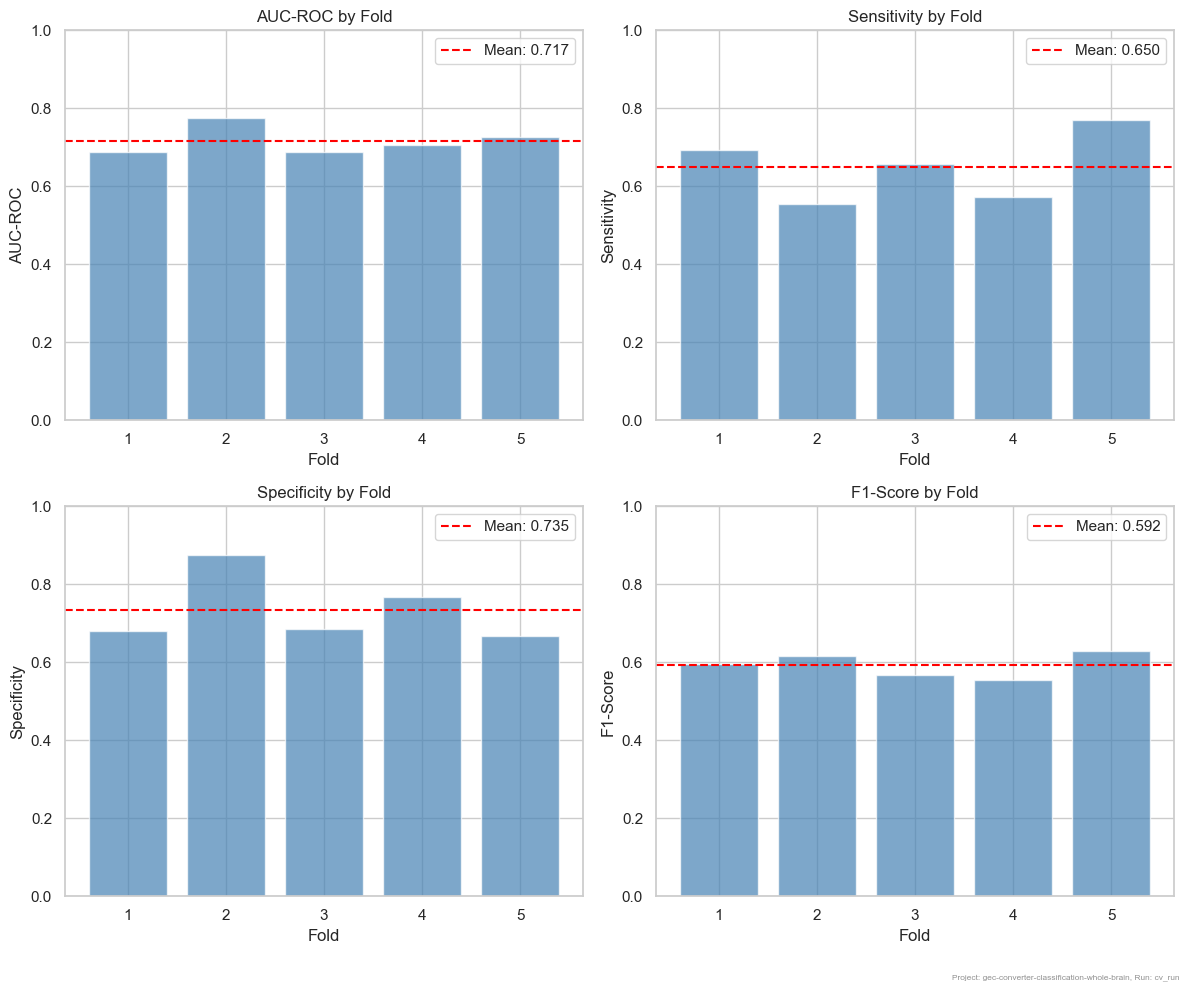

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metrics = ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']
titles = ['AUC-ROC', 'Sensitivity', 'Specificity', 'F1-Score']

for ax, metric, title in zip(axes.flat, metrics, titles):
    values = cv_results[metric]
    ax.bar(range(1, N_FOLDS+1), values, color='steelblue', alpha=0.7)
    ax.axhline(y=np.mean(values), color='red', linestyle='--', label=f'Mean: {np.mean(values):.3f}')
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.set_title(f'{title} by Fold')
    ax.set_xticks(range(1, N_FOLDS+1))
    ax.legend()
    ax.set_ylim(0, 1)

run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
try:
    wandb_run_name = wandb.run.name if wandb and wandb.run and wandb.run.name else "cv_run"
except Exception:
    wandb_run_name = "cv_run"
wandb_run_name = str(wandb_run_name).replace(" ", "-")
run_name = f"{wandb_run_name}_{run_timestamp}"

plt.figtext(
    0.99,
    0.01,
    f"Project: {WANDB_PROJECT}, Run: {run_name}",
    horizontalalignment='right',
    verticalalignment='bottom',
    fontsize=8,
    alpha=0.5,
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## Save Best Model and Results

In [14]:
run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
try:
    wandb_run_name = wandb.run.name if wandb and wandb.run and wandb.run.name else "cv_run"
except Exception:
    wandb_run_name = "cv_run"
wandb_run_name = str(wandb_run_name).replace(" ", "-")
run_name = f"{wandb_run_name}_{run_timestamp}"

run_artifact_dir = os.path.join(GEC_OUTPUT_DIR, run_name)
os.makedirs(run_artifact_dir, exist_ok=True)

model_filename = f"best_model_fold{best_fold}.pth"
model_file = os.path.join(run_artifact_dir, model_filename)
torch.save(best_model_state, model_file)
print(f"Saved best model to {model_file}")

results_to_save = {
    'run_name': run_name,
    'wandb_run_name': wandb_run_name,
    'timestamp': run_timestamp,
    'n_folds': N_FOLDS,
    'cv_results': cv_results,
    'cv_summary': {
        'auc_mean': float(np.mean(cv_results['val_auc'])),
        'auc_std': float(np.std(cv_results['val_auc'])),
        'sensitivity_mean': float(np.mean(cv_results['val_sensitivity'])),
        'specificity_mean': float(np.mean(cv_results['val_specificity'])),
        'f1_mean': float(np.mean(cv_results['val_f1']))
    },
    'best_fold': best_fold,
    'best_threshold': float(best_threshold_overall),
    'config': {
        'in_features': IN_FEATURES,
        'hidden_dim': HIDDEN_DIM,
        'latent_dim': LATENT_DIM,
        'cond_dim': COND_DIM,
        'num_heads': NUM_HEADS,
        'dropout': DROPOUT,
        'classifier_hidden': CLASSIFIER_HIDDEN,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'epochs': EPOCHS,
        'knn_k': KNN_K,
        'file_variant': FILE_VARIANT,
        'freeze_encoder': FREEZE_ENCODER,
        'gaae_checkpoint': GAAE_CHECKPOINT_PATH,
        'wb_root': WB_ROOT
    }
}

results_file = os.path.join(run_artifact_dir, "cv_results.json")
cv_results_serializable = {
    k: [float(v) for v in vals] for k, vals in cv_results.items()
}
with open(results_file, 'w') as f:
    json.dump(cv_results_serializable, f, indent=2)
print(f"Saved CV results to {results_file}")
print(f"\nUse this checkpoint directory for testing: {run_artifact_dir}")

Saved best model to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gec_whole_brain/cv_run_2026-03-24_01-43-49/best_model_fold2.pth
Saved CV results to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gec_whole_brain/cv_run_2026-03-24_01-43-49/cv_results.json

Use this checkpoint directory for testing: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gec_whole_brain/cv_run_2026-03-24_01-43-49
